(irk-exercises-section)=

# Implicit Runge-Kutta methods exercises

`````{exercise}
:label: ch3-ex-radauIA-order

Determine the order of the DIRK method shown below.

$$ \begin{array}{c|cc}
    \frac{1}{4} & \frac{1}{4} \\
    \frac{3}{4} & \frac{1}{2} & \frac{1}{4} \\ \hline
    & \frac{1}{2} & \frac{1}{2}
\end{array} $$

```{dropdown} Solution
Checking $B(k)$ condition

$$ \begin{align*}
    k &= 1: & LHS &= b_1c_1^0 + b_2c_2^0 = \frac{1}{2} + \frac{1}{2} = 1, \\
    && RHS &= 1 \qquad \checkmark \\
    k &= 2: & LHS &= b_1c_1 + b_2c_2 = \frac{1}{2}\cdot \frac{1}{4} + \frac{1}{2} \cdot \frac{3}{4} = \frac{1}{2}, \\
    && RHS &= \frac{1}{2} \qquad \checkmark \\
    k &= 3: & LHS &= b_1c_1^2 + b_2c_2^2 = \frac{1}{2} \cdot \frac{1}{16} + \frac{1}{2} \cdot \frac{9}{16} = \frac{5}{16}, \\
    && RHS &= \frac{1}{3}. \qquad \mathsf{x}
\end{align*} $$

Checking $C(1)$ condition

$$ \begin{align*}
    i &= 1: & LHS &= a_{11} + a_{12} = \frac{1}{4} + 0 = \frac{1}{4}, \\
    && RHS &= \frac{1}{1} c_1^1 = \frac{1}{4} \qquad \checkmark \\
    i &= 2: & LHS &= a_{21} + a_{22} = \frac{1}{2} + \frac{1}{4} = \frac{3}{4}, \\
    && RHS &= \frac{1}{1} c_2^1 = \frac{3}{4}. \qquad \checkmark
\end{align*} $$

Checking $D(1)$ condition

$$ \begin{align*}
    j &=1: & LHS &= b_1c_1^0a_{11} + b_2c_2^0a_{21} = \frac{1}{2} \cdot \frac{1}{4} + \frac{1}{2} \cdot \frac{1}{2} = \frac{3}{8}, \\
    && RHS &= \frac{1}{1}b_1(1-c_1^1) = \frac{1}{2}\left( 1 - \frac{1}{4} \right) = \frac{3}{8} \qquad \checkmark \\
    j &= 2: & LHS &= b_1c_1^0a_{12} + b_2c_2^0a_{22} = \frac{1}{2} \cdot 0 + \frac{1}{2} \cdot \frac{1}{4} = \frac{1}{8}, \\
    && RHS &= \frac{1}{1}b_2(1 - c_2^1) = \frac{1}{2} \left( 1 - \frac{3}{4} \right) = \frac{1}{8}. \qquad \checkmark
\end{align*} $$

Since $B(2)$, $C(1)$ and $D(1)$ conditions are all satisfied then this DIRK method is a second-order method.
```
`````

```````{exercise}
:label: ch3-ex-radauIIA-derivation

Derive a third-order Radau IIA method. Present your method in a Butcher tableau.

``````{dropdown} Solution

A third-order Radau IIA method requires $s = 2$ stages. The $c_1$ and $c_2$ coefficients are the roots of the Legendre polynomial $P_2(x) - P_1(x) = 0$

$$ \begin{align*}
    0 &= 1 + {2 \choose 1} {3 \choose 1} (x - 1) + {2 \choose 2} {4 \choose 2}(x - 1)^2 - 1 - {1 \choose 1} {2 \choose 1}(x - 1) \\
    &= 1 + 6(x - 1) + 6(x - 1)^2 - 1 - 2(x - 1) \\
    &= 6x^2 - 8x + 2 \\
    &= (3x - 1)(2x - 2).
\end{align*} $$

therefore $c_1 = \frac{1}{3}$ and $c_2 = 1$. The $a_{ij}$ and $b_i$ coefficients are chosen to satisfy the $B(3)$ and $C(2)$ conditions respectively

$$ \begin{align*}
    b_1 + b_2 &= 1, \\
    b_1c_1 + b_2c_2 &= \tfrac{1}{2}, \\
    a_{11} + b_{12} &= c_1, \\
    a_{21} + b_{22} &= c_2, \\
    a_{11}c_1 + a_{12}c_j &= \tfrac{1}{2}c_1^2, \\
    a_{21}c_1 + a_{22}c_2 &= \tfrac{1}{2}c_2^2.
\end{align*} $$

Note that we did not need all equations from the $B(3)$ condition since we only have 6 unknowns. Using Python or MATLAB to solve these gives

$$ \begin{array}{c|cc}
    \frac{1}{3} & \frac{5}{12} & -\frac{1}{12} \\
    1 & \frac{3}{4} & \frac{1}{4} \\ \hline
    & \frac{3}{4} & \frac{1}{4}
\end{array} $$

`````{tab-set}
````{tab-item} Python
```python
import sympy as sp

# Define symbolic variables
a11, a12, a21, a22, b1, b2, c1, c2, x = sp.symbols("a11, a12, a21, a22, b1, b2, c1, c2, x")
c1 = sp.Rational(1, 3)
c2 = 1

# Define order conditions
eq1 = b1 + b2 - 1
eq2 = b1 * c1 + b2 * c2 - sp.Rational(1,2)
eq3 = a11 + a12 - c1
eq4 = a21 + a22 - c2
eq5 = a11 * c1 + a12 * c2 - sp.Rational(1,2) * c1 ** 2
eq6 = a21 * c1 + a22 * c2 - sp.Rational(1,2) * c2 ** 2

# Solve order conditions
sp.solve((eq1, eq2, eq3, eq4, eq5, eq6))
```
````

````{tab-item} MATLAB
```python
syms a11 a12 a21 a22 b1 b2 c1 c2
c1 = 1/3;
c2 = 1;

% Define order conditions
eq1 = b1 + b2 == 1;
eq2 = b1 * c1 + b2 == 1/2;
eq3 = b1 * c1 ^ 2 + b2 == 1/3;
eq3 = a11 + a12 == c1;
eq4 = a21 + a22 == 1;
eq5 = a11 * c1 + a12 * c2 == 1/2 * c1^2;
eq6 = a21 * c1 + a22 * c2 == 1/2;

% Solve order conditions
solve(eq1, eq2, eq3, eq4, eq5, eq6)
```
````
`````

``````
```````

In [1]:
import sympy as sp

# Define symbolic variables
a11, a12, a21, a22, b1, b2, c1, c2, x = sp.symbols("a11, a12, a21, a22, b1, b2, c1, c2, x")
c1 = sp.Rational(1, 3)
c2 = 1

# Define order conditions
eq1 = b1 + b2 - 1
eq2 = b1 * c1 + b2 * c2 - sp.Rational(1,2)
eq3 = a11 + a12 - c1
eq4 = a21 + a22 - c2
eq5 = a11 * c1 + a12 * c2 - sp.Rational(1,2) * c1 ** 2
eq6 = a21 * c1 + a22 * c2 - sp.Rational(1,2) * c2 ** 2

# Solve order conditions
sp.solve((eq1, eq2, eq3, eq4, eq5, eq6))

{a11: 5/12, a12: -1/12, a21: 3/4, a22: 1/4, b1: 3/4, b2: 1/4}

```````{exercise}
:label: ch3-ex-single-ode

The following IVP is to be solved using the third-order Radau IIA method derived in {ref}`ch3-ex-radauIIA-derivation`

$$ y' = t - y, \qquad t \in [0, 2], \qquad y(0) = 1. $$

(a) &emps; Derive the matrix equation for which the solution gives the stage values for each step of the method for this IVP. 

```{dropdown} Solution
The Radau IIA method is 

$$ \begin{array}{c|cc}
    \frac{1}{3} & \frac{5}{12} & -\frac{1}{12} \\
    1 & \frac{3}{4} & \frac{1}{4} \\ \hline
    & \frac{3}{4} & \frac{1}{4}
\end{array} $$

so the stage value calculations are

$$ \begin{align*} 
  Y_1 &= y_n + h (\tfrac{5}{12} f(t_n + \tfrac{1}{3}h, Y_1) - \tfrac{1}{12} f(t_n + h, Y_2)), \\
  Y_2 &= y_n + h (\tfrac{3}{4} f(t_n + \tfrac{1}{3}h, Y_1) + \tfrac{1}{4} f(t_n + h, Y_2)).
\end{align*} $$

Since $f(t, y) = t - y$ then

$$ \begin{align*}
  Y_1 &= y_n + h(\tfrac{5}{12}(t_n + \tfrac{1}{3}h - Y_1) - \tfrac{1}{12} (t_n + h - Y_2)), \\
  Y_2 &= y_n + h(\tfrac{3}{4}(t_n + \tfrac{1}{3}h - Y_1) + \tfrac{1}{4}(t_n + h - Y_2)).
\end{align*} $$

Transposing the unknown terms to the LHS

$$ \begin{align*}
  (1 + \tfrac{5}{12}h) - \tfrac{1}{12}hY_2 &= y_n + \tfrac{1}{3}ht_n + \tfrac{1}{18}h^2, \\
  \tfrac{3}{4}hY_1 + (1 + \tfrac{1}{4}h)Y_2 &= y_n + ht_n + \tfrac{1}{2}h^2.
\end{align*} $$

which can be written as the matrix equation

$$ \begin{align*}
  \begin{pmatrix}
    1 + \frac{5}{12}h & -\frac{1}{12}h \\
    \frac{3}{4}h & 1 + \frac{1}{4}h
  \end{pmatrix}
  \begin{pmatrix} Y_1 \\ Y_2 \end{pmatrix} 
  =
  \begin{pmatrix}
    y_n + \frac{1}{3}ht_n + \frac{1}{18}h^2 \\
    y_n + ht_n + \frac{1}{2}h^2
  \end{pmatrix}.
\end{align*} $$
```

(b) &emsp; Compute the solution to this IVP using a step length of $h = 0.4$. Present the solution in a table with columns for $t_n$, $y_n$, $Y_1$ and $Y_2$. 

``````{dropdown} Solution

| $n$  | $t_n$  |    $y_n$    |   $Y_1$    |   $Y_2$    |
|:--:|:---:|:--------:|:--------:|:--------:|
|  0 | 0.0 | 1.000000 |    -     |    -     |
|  1 | 0.4 | 0.740206 | 0.885911 | 0.740206 |
|  2 | 0.8 | 0.698076 | 0.707741 | 0.698076 |
|  3 | 1.2 | 0.801804 | 0.720307 | 0.801804 |
|  4 | 1.6 | 1.003271 | 0.860687 | 1.003271 |
|  5 | 2.0 | 1.270233 | 1.086715 | 1.270233 |

`````{tab-set}
````{tab-item} Python
```python
import numpy as np

# Define ODE function
def f(t, y):
    return t - y

# Define IVP parameters
tspan = [0, 2]
y0 = 1
h = 0.4

# Determine the number of steps required
nsteps = int((tspan[1] - tspan[0]) / h)

# Define solution arrays and assign initial values
t = np.zeros(nsteps + 1)
y = np.zeros(nsteps + 1)
t[0] = tspan[0]
y[0] = y0

# Define coefficient matrix for the linear system for the stage values and compute inverse (constant for all steps)
A = np.array([[ 1 + 5/12 * h, -1/12 * h],
              [ 3/4 * h, 1 + 1/4 * h ]])
invA = np.linalg.inv(A)

# Output table headings
print("| n  | tn  |    yn    |   Y_1    |   Y_2    |")
print("|:--:|:---:|:--------:|:--------:|:--------:|")
print(f"|  {0} | {t[0]:0.1f} | {y[0]:0.6f} |    -     |    -     |")

# Loop through steps
for n in range(nsteps):

    # Compute stage values
    b = np.array([ y[n] + 1/3 * h * t[n] + 1/18 * h**2 , y[n] + h * t[n] + 1/2 * h**2 ])
    Y = invA @ b

    # Compute solution for the next step
    y[n+1] = y[n] + h * (3/4 * f(t[n] + 1/3 * h, Y[0]) + 1/4 * f(t[n] + h, Y[1]))
    t[n+1] = t[n] + h

    # Output table row
    print(f"|  {n+1} | {t[n+1]:0.1f} | {y[n]:0.6f} | {Y[0]:0.6f} | {Y[1]:0.6f} |")
```
````

````{tab-item} MATLAB
```matlab
% Define ODE function
f = @(t, y) t - y;

% Define IVP parameters
tspan = [0, 2];
y0 = 1;
h = 0.4;

% Determine the number of steps required
nsteps = floor((tspan(2) - tspan(1)) / h);

% Define solution arrays and assign initial values
t = zeros(nsteps + 1, 1);
y = zeros(nsteps + 1, 1);
t(1) = tspan(1);
y(1) = y0;

% Define coefficient matrix for the lienar system for the stage values and
% compute the inverse (constant for all steps)
A = [ 1 + 5/12 * h, -1/12 * h ;
      3/4 * h, 1 + 1/4 * h ];
invA = inv(A);

% Output table headings
fprintf("| n  | tn  |    yn    |   Y_1    |   Y_2    |")
fprintf("|:--:|:---:|:--------:|:--------:|:--------:|")
fprintf("|  %i | %0.1f | %0.6f |    -     |    -     |", 0, t(1), y(1))

% Loop through steps
for n = 1 : nsteps
    
    % Compute stage values
    b = [ y(n) + 1/3 * h * t(n) + 1/18 * h^2 ;
          y(n) + h * t(n) + 1/2 * h^2 ];
    Y = invA * b;

    % Compute solution for the next step
    y(n+1) = y(n) + h * (3/4 * f(t(n) + 1/3 * h, Y(1)) + 1/4 * f(t(n) + h, Y(2)));
    t(n+1) = t(n) + h;

    % Output table row
    fprintf("|  %i | %0.1f | %0.6f | %0.6f | %0.6f |\n", n+1, t(n+1), y(n+1), Y(1), Y(2))
end
```
````
`````

``````

(c) &emsp; The exact solution for this IVP is $y = t + 2e^{-t} + 1$. Produce a plot comparing your solution using the Radua IIA method to the exact solution.

``````{dropdown} Solution

```{glue:figure} ex3.3_plot
```

`````{tab-set}
````{tab-item} Python
```python
# Define exact solution 
def exact(t):
    return t + 2 * np.exp(-t) - 1

# Calculate exact solution
t_exact = np.linspace(tspan[0], tspan[1], 100)
y_exact = exact(t_exact)

import matplotlib.pyplot as plt

plt.subplots()
plt.plot(t_exact, y_exact, 'k', label="Exact")
plt.plot(t, y, 'b-o', label="Radau IIA")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("$y' = t - y$, $t \in [0, 2]$, $y(0) = 1$")
plt.legend()
plt.show()
```
````

````{tab-item} MATLAB
```matlab
% Define exact solution
exact = @(t) t + 2 * exp(-t) - 1;

% Calculate exact solution
t_exact = linspace(tspan(1), tspan(2), 100);
y_exact = exact(t_exact);

% Plot solution
plot(t_exact, y_exact, 'k-', LineWidth=2)
hold on
plot(t, y, 'b-o', LineWidth=2, MarkerFaceColor='b')
hold off

xlabel("$t$", Interpreter="latex")
ylabel("$y$", Interpreter="latex")
title("$y' = t - y$, $t \in [0, 2]$, $y(0)=1$", Interpreter="latex")
legend(["Exact", "Radau IIA"], location="northwest")
axis padded
```
````
`````

``````

(d) &emsp; Estimate the order of your Radau IIA method using the numerical solutions to $y(2)$ with $h = 0.1$ and $h = 0.05$.

``````{dropdown} Solution

The errors at $y(2)$ are $E(h=0.1) = 7.33 \times 10^{-6}$ and $E(h = 0.05) = 9.28 \times 10^{-7}$, therefore the order estimate is

$$ \begin{align*}
    n \approx \frac{\log(7.33 \times 10^{-6}) - \log(9.28 \times 10^{-7})}{\log(0.1) - \log(0.05)} = 2.98
\end{align*} $$

So this shows that this Radau IIA method is a third-order method as expected.


`````{tab-set}
````{tab-item} Python
```python
# Define IVP parameters
tspan = [0, 2]
y0 = 1

# Calculate solution using h = 0.1
h = 0.1

# Determine the number of steps required
nsteps = int((tspan[1] - tspan[0]) / h)

# Define solution arrays and assign initial values
t = np.zeros(nsteps + 1)
y = np.zeros(nsteps + 1)
t[0] = tspan[0]
y[0] = y0

# Define coefficient matrix for the linear system for the stage values and compute inverse (constant for all steps)
A = np.array([[ 1 + 5/12 * h, -1/12 * h],
              [ 3/4 * h, 1 + 1/4 * h ]])
invA = np.linalg.inv(A)

# Loop through steps
for n in range(nsteps):

    # Compute stage values
    b = np.array([ y[n] + 1/3 * h * t[n] + 1/18 * h**2 , y[n] + h * t[n] + 1/2 * h**2 ])
    Y = invA @ b

    # Compute solution for the next step
    y[n+1] = y[n] + h * (3/4 * f(t[n] + 1/3 * h, Y[0]) + 1/4 * f(t[n] + h, Y[1]))
    t[n+1] = t[n] + h

# Calculate error for y(2)
E1 = abs(exact(2) - y[-1])

# Calculate solution using h = 0.05
h = 0.05

# Determine the number of steps required
nsteps = int((tspan[1] - tspan[0]) / h)

# Define solution arrays and assign initial values
t = np.zeros(nsteps + 1)
y = np.zeros(nsteps + 1)
t[0] = tspan[0]
y[0] = y0

# Define coefficient matrix for the linear system for the stage values and compute inverse (constant for all steps)
A = np.array([[ 1 + 5/12 * h, -1/12 * h],
              [ 3/4 * h, 1 + 1/4 * h ]])
invA = np.linalg.inv(A)

# Loop through steps
for n in range(nsteps):

    # Compute stage values
    b = np.array([ y[n] + 1/3 * h * t[n] + 1/18 * h**2 , y[n] + h * t[n] + 1/2 * h**2 ])
    Y = invA @ b

    # Compute solution for the next step
    y[n+1] = y[n] + h * (3/4 * f(t[n] + 1/3 * h, Y[0]) + 1/4 * f(t[n] + h, Y[1]))
    t[n+1] = t[n] + h

# Calculate error for y(2)
E2 = abs(exact(2) - y[-1])

# Estimate order
order = (np.log(E1) - np.log(E2)) / (np.log(0.1) - np.log(0.05))

# Output results
print(f"h = 0.1: Error = {E1:0.2e}")
print(f"h = 0.05: Error = {E2:0.2e}")
print(f"order = {order:0.2f}")
```
````

````{tab-item} MATLAB
```matlab
% Define IVP parameters
tspan = [0, 2];
y0 = 1;

% Solve IVP using h = 0.1
h = 0.1;

% Determine the number of steps required
nsteps = floor((tspan(2) - tspan(1)) / h);

% Define solution arrays and assign initial values
t = zeros(nsteps + 1, 1);
y = zeros(nsteps + 1, 1);
t(1) = tspan(1);
y(1) = y0;

% Define coefficient matrix for the lienar system for the stage values and
% compute the inverse (constant for all steps)
A = [ 1 + 5/12 * h, -1/12 * h ;
      3/4 * h, 1 + 1/4 * h ];
invA = inv(A);

% Loop through steps
for n = 1 : nsteps
    
    % Compute stage values
    b = [ y(n) + 1/3 * h * t(n) + 1/18 * h^2 ;
          y(n) + h * t(n) + 1/2 * h^2 ];
    Y = invA * b;

    % Compute solution for the next step
    y(n+1) = y(n) + h * (3/4 * f(t(n) + 1/3 * h, Y(1)) + 1/4 * f(t(n) + h, Y(2)));
    t(n+1) = t(n) + h;
end

% Calculate error for y(2)
E1 = abs(exact(2) - y(end));

% Solve IVP using h = 0.05
h = 0.05;

% Determine the number of steps required
nsteps = floor((tspan(2) - tspan(1)) / h);

% Define solution arrays and assign initial values
t = zeros(nsteps + 1, 1);
y = zeros(nsteps + 1, 1);
t(1) = tspan(1);
y(1) = y0;

% Define coefficient matrix for the lienar system for the stage values and
% compute the inverse (constant for all steps)
A = [ 1 + 5/12 * h, -1/12 * h ;
      3/4 * h, 1 + 1/4 * h ];
invA = inv(A);

% Loop through steps
for n = 1 : nsteps
    
    % Compute stage values
    b = [ y(n) + 1/3 * h * t(n) + 1/18 * h^2 ;
          y(n) + h * t(n) + 1/2 * h^2 ];
    Y = invA * b;

    % Compute solution for the next step
    y(n+1) = y(n) + h * (3/4 * f(t(n) + 1/3 * h, Y(1)) + 1/4 * f(t(n) + h, Y(2)));
    t(n+1) = t(n) + h;
end

% Calculate error for y(2)
E2 = abs(exact(2) - y(end));

% Estimate order
order = (log(E1) - log(E2)) / (log(0.1) - log(0.05))

% Output results
fprintf("h = 0.1: Error = %0.2e", E1)
fprintf("h = 0.05: Error = %0.2f", E2)
fprintf("order = %0.2f", order)
```
````
`````

``````


```````

In [2]:
import numpy as np

# Define ODE function
def f(t, y):
    return t - y

# Define IVP parameters
tspan = [0, 2]
y0 = 1
h = 0.4

# Determine the number of steps required
nsteps = int((tspan[1] - tspan[0]) / h)

# Define solution arrays and assign initial values
t = np.zeros(nsteps + 1)
y = np.zeros(nsteps + 1)
t[0] = tspan[0]
y[0] = y0

# Define coefficient matrix for the linear system for the stage values and compute inverse (constant for all steps)
A = np.array([[ 1 + 5/12 * h, -1/12 * h],
              [ 3/4 * h, 1 + 1/4 * h ]])
invA = np.linalg.inv(A)

# Output table headings
print("| n  | tn  |    yn    |   Y_1    |   Y_2    |")
print("|:--:|:---:|:--------:|:--------:|:--------:|")
print(f"|  {0} | {t[0]:0.1f} | {y[0]:0.6f} |    -     |    -     |")

# Loop through steps
for n in range(nsteps):

    # Compute stage values
    b = np.array([ y[n] + 1/3 * h * t[n] + 1/18 * h**2 , y[n] + h * t[n] + 1/2 * h**2 ])
    Y = invA @ b

    # Compute solution for the next step
    y[n+1] = y[n] + h * (3/4 * f(t[n] + 1/3 * h, Y[0]) + 1/4 * f(t[n] + h, Y[1]))
    t[n+1] = t[n] + h

    # Output table row
    print(f"|  {n+1} | {t[n+1]:0.1f} | {y[n+1]:0.6f} | {Y[0]:0.6f} | {Y[1]:0.6f} |")

| n  | tn  |    yn    |   Y_1    |   Y_2    |
|:--:|:---:|:--------:|:--------:|:--------:|
|  0 | 0.0 | 1.000000 |    -     |    -     |
|  1 | 0.4 | 0.740206 | 0.885911 | 0.740206 |
|  2 | 0.8 | 0.698076 | 0.707741 | 0.698076 |
|  3 | 1.2 | 0.801804 | 0.720307 | 0.801804 |
|  4 | 1.6 | 1.003271 | 0.860687 | 1.003271 |
|  5 | 2.0 | 1.270233 | 1.086715 | 1.270233 |


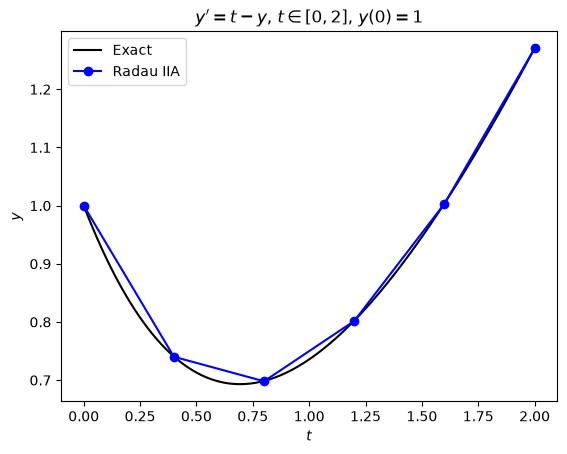

In [3]:
# Define exact solution 
def exact(t):
    return t + 2 * np.exp(-t) - 1

# Calculate exact solution
t_exact = np.linspace(tspan[0], tspan[1], 100)
y_exact = exact(t_exact)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.plot(t_exact, y_exact, 'k', label="Exact")
plt.plot(t, y, 'b-o', label="Radau IIA")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("$y' = t - y$, $t \\in [0, 2]$, $y(0) = 1$")
plt.legend()
plt.show()

from myst_nb import glue
glue("ex3.3_plot", fig, display=False)

In [4]:
# Define IVP parameters
tspan = [0, 2]
y0 = 1

# Calculate solution using h = 0.1
h = 0.1

# Determine the number of steps required
nsteps = int((tspan[1] - tspan[0]) / h)

# Define solution arrays and assign initial values
t = np.zeros(nsteps + 1)
y = np.zeros(nsteps + 1)
t[0] = tspan[0]
y[0] = y0

# Define coefficient matrix for the linear system for the stage values and compute inverse (constant for all steps)
A = np.array([[ 1 + 5/12 * h, -1/12 * h],
              [ 3/4 * h, 1 + 1/4 * h ]])
invA = np.linalg.inv(A)

# Loop through steps
for n in range(nsteps):

    # Compute stage values
    b = np.array([ y[n] + 1/3 * h * t[n] + 1/18 * h**2 , y[n] + h * t[n] + 1/2 * h**2 ])
    Y = invA @ b

    # Compute solution for the next step
    y[n+1] = y[n] + h * (3/4 * f(t[n] + 1/3 * h, Y[0]) + 1/4 * f(t[n] + h, Y[1]))
    t[n+1] = t[n] + h

# Calculate error for y(2)
E1 = abs(exact(2) - y[-1])

# Calculate solution using h = 0.05
h = 0.05

# Determine the number of steps required
nsteps = int((tspan[1] - tspan[0]) / h)

# Define solution arrays and assign initial values
t = np.zeros(nsteps + 1)
y = np.zeros(nsteps + 1)
t[0] = tspan[0]
y[0] = y0

# Define coefficient matrix for the linear system for the stage values and compute inverse (constant for all steps)
A = np.array([[ 1 + 5/12 * h, -1/12 * h],
              [ 3/4 * h, 1 + 1/4 * h ]])
invA = np.linalg.inv(A)

# Loop through steps
for n in range(nsteps):

    # Compute stage values
    b = np.array([ y[n] + 1/3 * h * t[n] + 1/18 * h**2 , y[n] + h * t[n] + 1/2 * h**2 ])
    Y = invA @ b

    # Compute solution for the next step
    y[n+1] = y[n] + h * (3/4 * f(t[n] + 1/3 * h, Y[0]) + 1/4 * f(t[n] + h, Y[1]))
    t[n+1] = t[n] + h

# Calculate error for y(2)
E2 = abs(exact(2) - y[-1])

# Estimate order
order = (np.log(E1) - np.log(E2)) / (np.log(0.1) - np.log(0.05))

# Output results
print(f"h = 0.1: Error = {E1:0.2e}")
print(f"h = 0.05: Error = {E2:0.2e}")
print(f"order = {order:0.2f}")

h = 0.1: Error = 7.33e-06
h = 0.05: Error = 9.28e-07
order = 2.98


```````{exercise}
:label: ch3-ex-stiff

Consider following IVP

$$ \begin{align*}
  y_1' &= -1000 y_1 + y_2, & y_1(0) &= 1, \\
  y_2' &= -y_2, & y_2(0) &= 1.
\end{align*} $$

(a) &emsp; Compute the solution to this IVP over $t\in [0, 5]$ using the Radau IIA method from the previous exercise with a step length of $h = 0.1$. Produce a plot of the solutions to $y_1$ and $y_2$ against $t$.

``````{dropdown} Solution
```{glue:figure} ex3.4_plot_radauIIA
```

`````{tab-set}
````{tab-item} Python
```python
import numpy as np
import matplotlib.pyplot as plt

def jac(f, t, y):
    J = np.zeros((len(y), len(y)))
    epsilon = 1e-6
    for i in range(len(y)):
        y_plus_epsilon = y.astype(float)
        y_plus_epsilon[i] += epsilon
        J[:,i] = (f(t, y_plus_epsilon) - f(t,y)) / epsilon

    return J


def radauIIA(f, tpsan, y0, h):
    
    # Determine the number of ODEs in the system
    N = len(y0)

    # Calculate the number of steps required
    nsteps = int((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Define Butcher tableau
    A = np.array([[5/12, -1/12],
                  [3/4, 1/4]])
    b = np.array([3/4, 1/4])
    c = np.array([1/3, 1])
    s = 2

    # Define maximum Newton iterations
    max_iter = 10

    # Loop through steps
    for n in range(nsteps):

        # Use Newton's method to solve for the stage values
        Y = np.zeros(N * s)
        F = np.zeros(N * s)
        e = np.ones(N)
        J = jac(f, t[n], y[n,:])

        for k in range(max_iter):
            F[:N] = f(t[n] + c[0] * h, Y[:N])
            F[N:] = f(t[n] + c[1] * h, Y[N:])
            g = Y - np.kron(e, y[n,:]) - h * np.kron(A, np.eye(N)) @ F
            delta_Y = np.linalg.solve(np.eye(N * s) - h * np.kron(A, J), -g)
            Y += delta_Y
            if np.linalg.norm(delta_Y) < 1e-6:
                break
        
        y[n+1,:] = y[n,:] + h * np.kron(b.T, np.eye(N)) @ F
        t[n+1] = t[n] + h

    return t, y


def f(t, y):
    return np.array([-1000 * y[0] + y[1], -y[1]])

# Define IVP
tspan = [0, 5]
y0 = [1, 1]
h = 0.1

# Solve IVP
t, y = radauIIA(f, tspan, y0, h)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y[:,0], "b", label="$y_1$")
plt.plot(t, y[:,1], "r", label="$y_2$")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("Radau IIA")
plt.legend()
plt.show()
```
````

````{tab-item} MATLAB
```matlab
function J = jac(f, t, y)

N = length(y);
J = zeros(N, N);
epsilon = 1e-2;
for i = 1 : N
    y_plus_epsilon = y;
    y_plus_epsilon(i) = y_plus_epsilon(i) + epsilon;
    J(:, i) = (f(t, y_plus_epsilon) - f(t, y)) / epsilon;
end

end

function [t, y] = radauIIA(f, tspan, y0, h)

% Determine the number of ODEs in the system
N = length(y0);

% Calculate the number of steps required
nsteps = floor((tspan(2) - tspan(1)) / h);

% Define solution arrays and assign initial values
t = zeros(nsteps + 1, 1);
y = zeros(nsteps + 1, N);
t(1) = tspan(1);
y(1,:) = y0;

% Define Butcher tableau
A = [ 5/12, -1/12 ; 3/4, 1/4 ];
b = [ 3/4 ; 1/4 ];
c = [ 1/3 ; 1 ];
s = 2;

% Define maximum Newton iterations
max_iter = 10;

% Loop through steps
for n = 1 : nsteps

    % Use Newton's method to solve for the stage values
    Y = zeros(N * s, 1);
    F = zeros(N * s, 1);
    e = ones(N, 1);
    J = jac(f, t(n), y(n,:));

    for k = 1 : max_iter
        F = [f(t(n) * c(1) * h, Y(1:N)') ;
             f(t(n) * c(2) * h, Y(N+1:end)')];
        g = Y - kron(e, y(n,:)') - h * kron(A, eye(N)) * F;
        delta_Y = (eye(N * s) - h * kron(A, J)) \ -g;
        Y = Y + delta_Y;
        if norm(delta_Y) < 1e-6
            break
        end
    end

    y(n+1,:) = y(n,:) + (h * kron(b', eye(N)) * F)';
    t(n+1) = t(n) + h;
end

end

% Define ODE function
f= @(t, y) [ -100 * y(1) + y(2) ; -y(2) ];

% Define IVP parameters
tspan = [0, 5];     % boundaries of the t domain
y0 = [1, 1];        % initial value of the solution
h = 0.1;            % step length

% Calculate the solution to the IVP
[t, y] = radauIIA(f, tspan, y0, h);

% Plot solution
plot(t, y(:,1), LineWidth=2)
hold on
plot(t, y(:,2), LineWidth=2)
hold off

xlabel("$t$", Interpreter="latex")
ylabel("$y$", Interpreter="latex")
title("Radau IIA")
legend(["$y_1$", "$y_2$"], Interpreter="latex")
axis padded
```
````

`````
``````

(b) &emsp; Attempt to solve this IVP using the RK4 method with the same step length. What do you notice about the result?

````{dropdown} Solution
```{glue:figure} ex3.4_plot_rk4
```
The solution is unstable.
````

(c) &emsp; Solve this IVP using the {prf:ref}`Fehlberg 4(5)<fehlbergs-method-equation>` explicit Runge-Kutta method. Record the time taken for both methods to compute the solution and determine value of the smallest step length used in the Fehlberg's method solution. What does this suggest about this system?

``````{dropdown} Solution
The Radau IIA method took 0.008 seconds to compute whereas the Runge-Kutta Fehlberg 4(5) method took 0.107 seconds to compute (these times will vary depending on the machine used). The smallest step length used in Fehlberg's method was $h = 0.000042$. This suggests that this is a stiff system since the minimum step length used in Fehlberg's method is very small compared to the one used for the Radau IIA method.

`````{tab-set}
````{tab-item} Python
```python
# Define RKF45 function
def rkf45(f, tspan, y0, atol=1e-6, rtol=1e-3):

    # Determine the number of ODEs in the system
    N = len(y0)

    # Define solution arrays and assign initial values
    max_steps = 1000000
    t = np.zeros(max_steps + 1)
    y = np.zeros((max_steps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Compute initial step length
    h = 0.8 * rtol ** (1 / 3)

    # Loop through steps
    n = 0
    while t[n] < tspan[-1]:

        # Compute the stage values
        k1 = f(t[n], y[n,:])
        k2 = f(t[n] + 1/4 * h, y[n,:] + 1/4 * h * k1)
        k3 = f(t[n] + 3/8 * h, y[n,:] + h * (3/32 * k1 + 9/32 * k2))
        k4 = f(t[n] + 12/13 * h, y[n,:] + h * (1932/2197 * k1 - 7200/2197 * k2 + 7296/2197 * k3))
        k5 = f(t[n] + h, y[n,:] + h * (439/216 * k1 - 8 * k2 + 3680/513 * k3 - 845/4104 * k4))
        k6 = f(t[n] + 1/2 * h, y[n,:] + h * (-8/27 * k1 + 2 * k2 - 3544/2565 * k3 + 1859/4104 * k4 - 11/40 * k5))

        # Compute the 4th and 5th order solutions for the next step
        y5 = y[n,:] + h * (16/135 * k1 + 6656/12825 * k3 + 28561/56430 * k4 - 9/50 * k5 + 2/55 * k6)
        y4 = y[n,:] + h * (25/216 * k1 + 1408/2565 * k3 + 2197/4104 * k4 - 1/5 * k5)

        # Compute Delta
        e = np.abs(y5 - y4)
        s = atol + rtol * np.maximum(np.abs(y[n,:]), np.abs(y5))
        Delta = np.sqrt(np.mean((e / s)**2))

        # Check if current step was successful
        if Delta <= 1:
            y[n+1,:] = y5
            t[n+1] = t[n] + h
            n += 1

        # Compute ratio of new step to old
        r = min(5, max(0.1, 0.8 * Delta**(-1/5)))

        # Update h
        h = min(r * h, tspan[-1] - t[n])

    return t[:n+1], y[:n+1,:]


# Solve IVP using RKF45 and Radau IIA methods and record the time taken for each one
import time

start = time.time()
t_rkf45, y_rkf45 = rkf45(f, tspan, y0)
rkf45_time = time.time() - start

start = time.time()
t, y_radauIIA = radauIIA(f, tspan, y0, h)
radauIIA_time = time.time() - start

print(f"RKF45 time: {rkf45_time:0.3f}")
print(f"radauIIA time: {radauIIA_time:0.3f}")
print(f"smallest step length used by RKF45: h = {np.min(t_rkf45[1:] - t_rkf45[:-1]):0.6f}")
```
````

````{tab-item} MATLAB
```matlab
% Define RKF45 function
function [t, y] = rkf45(f, tspan, y0, atol, rtol)

% Determine the number of ODEs in the system
N = length(y0);

% Define solution arrays and assign initial values
max_steps = 100000;
t = zeros(max_steps, 1);
y = zeros(max_steps, N);
t(1) = tspan(1);
y(1,:) = y0;

% Compute initial step length
h = 0.8 * rtol^(1/5);

% Loop through steps
n = 1;

while t(n) < tspan(2)

    % Compute stage values
    k1 = f(t(n), y(n,:));
    k2 = f(t(n) + 1/4 * h, y(n,:) + 1/4 * h * k1);
    k3 = f(t(n) + 3/8 * h, y(n,:) + h * (3/32 * k1 + 9/32 * k2));
    k4 = f(t(n) + 12/13 * h, y(n,:) + h * (1932/2197 * k1 - 7200/2197 * k2 + 7296/2197 * k3));
    k5 = f(t(n) + h, y(n,:) + h * (439/216 * k1 - 8 * k2 + 3680/513 * k3 - 845/4104 * k4));
    k6 = f(t(n) + 1/2 * h, y(n,:) + h * (-8/27 * k1 + 2 * k2 - 3544/2565 * k3 + 1859/4104 * k4 - 11/40 * k5));

    % Compute 4th and 5th order solution
    y5 = y(n,:) + h * (16/135 * k1 + 6656/12825 * k3 + 28561/56430 * k4 - 9/50 * k5 + 2/55 * k6);
    y4 = y(n,:) + h * (25/216 * k1 + 1408/2565 * k3 + 2197/4104 * k4 - 1/5 * k5);

    % Compute Delta
    e = abs(y5 - y4);
    s = atol + rtol * max(abs(y(n,:)), abs(y5));
    Delta = sqrt(mean((e ./ s).^2));

    % Check if current step was successful
    if Delta <= 1
        y(n+1,:) = y5;
        t(n+1) = t(n) + h;
        n = n + 1;
    end

    % Update h
    r = min(5, max(0.1, 0.8 * Delta.^(-1/5)));
    h = min(r * h, tspan(2) - t(n));

end

t(n+1:end) = [];
y(n+1:end,:) = [];

end


% Calculate the solution to the IVP using RKF45
tic;
[t_rkf45, y_rkf45] = rkf45(@(t, y)f(t, y)', tspan, y0, 1e-6, 1e-3);
rkf45_time = toc;

% Calculate the solution to the IVP using Radau IIA
tic;
[t_radauIIA, y_radauIIA] = radauIIA(f, tspan, y0, h);
radauIIA_time = toc;

% Output results
fprintf("RKF45 time: %0.3f seconds", rkf45_time)
fprintf("RadauIIA time: %0.3f seconds", radauIIA_time)
fprintf("smallest step length used by RKF45: h = %f", min(t_rkf45(2:end) - t_rkf45(1:end-1)))
```
````
`````

``````

```````

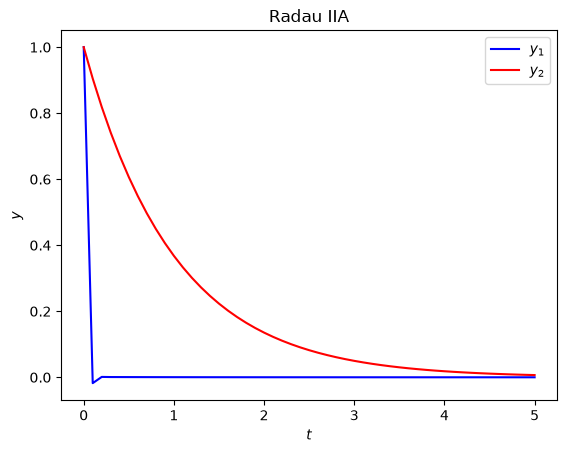

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def jac(f, t, y):
    N = len(y)
    J = np.zeros((N, N))
    I = np.eye(N)
    epsilon = 1e-6
    
    for i in range(N):
        J[:,i] = (f(t, y + epsilon * I[:,i]) - f(t,y)) / epsilon

    return J


def radauIIA(f, tspan, y0, h):
    
    # Determine the number of ODEs in the system
    N = len(y0)

    # Calculate the number of steps required
    nsteps = int((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Define Butcher tableau
    A = np.array([[5/12, -1/12],
                  [3/4, 1/4]])
    b = np.array([3/4, 1/4])
    c = np.array([1/3, 1])
    s = 2
    e = np.ones(s)
    
    # Define maximum Newton iterations
    max_iter = 10

    # Loop through steps
    for n in range(nsteps):

        # Use Newton's method to solve for the stage values
        Y = np.kron(e, y[n,:])
        F = np.zeros(N * s)
        Jf = jac(f, t[n], y[n,:])
        JG = np.eye(N * s) - h * np.kron(A, Jf)

        for k in range(max_iter):
            F[:N] = f(t[n] + c[0] * h, Y[:N])
            F[N:] = f(t[n] + c[1] * h, Y[N:])
            G = Y - np.kron(e, y[n,:]) - h * np.kron(A, np.eye(N)) @ F
            delta_Y = np.linalg.solve(JG, -G)
            Y += delta_Y

            if np.linalg.norm(delta_Y) < 1e-6:
                break

        y[n+1,:] = y[n,:] + h * np.kron(b.T, np.eye(N)) @ F
        t[n+1] = t[n] + h

    return t, y


def f(t, y):
    return np.array([-1000 * y[0] + y[1], -y[1]])

# Define IVP
tspan = [0, 5]
y0 = [1, 1]
h = 0.1

# Solve IVP
t, y = radauIIA(f, tspan, y0, h)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y[:,0], "b", label="$y_1$")
plt.plot(t, y[:,1], "r", label="$y_2$")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("Radau IIA")
plt.legend()
plt.show()

from myst_nb import glue
glue("ex3.4_plot_radauIIA", fig, display=False)

/var/folders/yr/fnkjc2p11wn3t_ddm5d7zkf40000gn/T/ipykernel_45814/2854399145.py:67: RuntimeWarning: overflow encountered in scalar multiply
  return np.array([-1000 * y[0] + y[1], -y[1]])
/var/folders/yr/fnkjc2p11wn3t_ddm5d7zkf40000gn/T/ipykernel_45814/514101592.py:17: RuntimeWarning: invalid value encountered in add
  y[n+1,:] = y[n,:] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4);


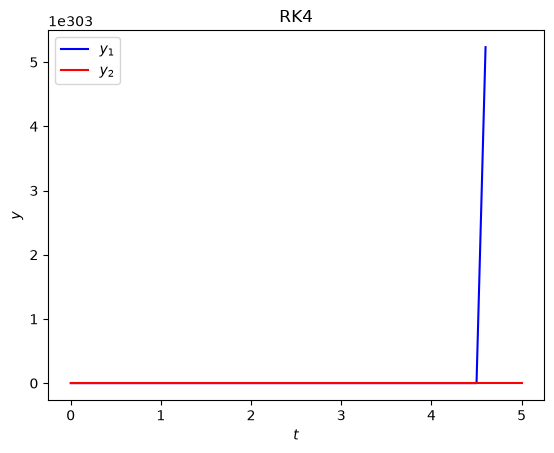

In [6]:
# Define RK4 method function
def rk4(f, tspan, y0, h):

    nsteps = int((tspan[1] - tspan[0]) / h)
    m = len(y0)
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, m))

    t[0] = tspan[0]
    y[0,:] = y0
    
    for n in range(nsteps):
        k1 = f(t[n], y[n,:])
        k2 = f(t[n] + 0.5 * h, y[n,:] + 0.5 * h * k1)
        k3 = f(t[n] + 0.5 * h, y[n,:] + 0.5 * h * k2)
        k4 = f(t[n] + h, y[n,:] + h * k3)
        y[n+1,:] = y[n,:] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4);
        t[n+1] = t[n] + h

    return t, y


# Define IVP
tspan = [0, 5]
y0 = [1.0, 1.0]
h = 0.1

# Solve IVP
t, y = rk4(f, tspan, y0, h)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y[:,0], "b", label="$y_1$")
plt.plot(t, y[:,1], "r", label="$y_2$")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("RK4")
plt.legend()
plt.show()

from myst_nb import glue
glue("ex3.4_plot_rk4", fig, display=False)

In [7]:
# Define RKF45 function
def rkf45(f, tspan, y0, atol=1e-6, rtol=1e-3):

    # Determine the number of ODEs in the system
    N = len(y0)

    # Define solution arrays and assign initial values
    max_steps = 1000000
    t = np.zeros(max_steps + 1)
    y = np.zeros((max_steps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Compute initial step length
    h = 0.8 * rtol ** (1 / 5)

    # Loop through steps
    n = 0
    while t[n] < tspan[-1]:

        # Compute the stage values
        k1 = f(t[n], y[n,:])
        k2 = f(t[n] + 1/4 * h, y[n,:] + 1/4 * h * k1)
        k3 = f(t[n] + 3/8 * h, y[n,:] + h * (3/32 * k1 + 9/32 * k2))
        k4 = f(t[n] + 12/13 * h, y[n,:] + h * (1932/2197 * k1 - 7200/2197 * k2 + 7296/2197 * k3))
        k5 = f(t[n] + h, y[n,:] + h * (439/216 * k1 - 8 * k2 + 3680/513 * k3 - 845/4104 * k4))
        k6 = f(t[n] + 1/2 * h, y[n,:] + h * (-8/27 * k1 + 2 * k2 - 3544/2565 * k3 + 1859/4104 * k4 - 11/40 * k5))

        # Compute the 4th and 5th order solutions for the next step
        y5 = y[n,:] + h * (16/135 * k1 + 6656/12825 * k3 + 28561/56430 * k4 - 9/50 * k5 + 2/55 * k6)
        y4 = y[n,:] + h * (25/216 * k1 + 1408/2565 * k3 + 2197/4104 * k4 - 1/5 * k5)

        # Compute Delta
        e = np.abs(y5 - y4)
        s = atol + rtol * np.maximum(np.abs(y[n,:]), np.abs(y5))
        Delta = np.sqrt(np.mean((e / s)**2))

        # Check if current step was successful
        if Delta <= 1:
            y[n+1,:] = y5
            t[n+1] = t[n] + h
            n += 1

        # Compute ratio of new step to old
        r = min(5, max(0.1, 0.8 * Delta**(-1/5)))

        # Update h
        h = min(r * h, tspan[-1] - t[n])

    return t[:n+1], y[:n+1,:]


# Solve IVP using RKF45 and Radau IIA methods and record the time taken for each one
import time

start = time.time()
t_rkf45, y_rkf45 = rkf45(f, tspan, y0)
rkf45_time = time.time() - start

start = time.time()
t, y_radauIIA = radauIIA(f, tspan, y0, h)
radauIIA_time = time.time() - start

print(f"RKF45 time: {rkf45_time:0.3f}")
print(f"radauIIA time: {radauIIA_time:0.3f}")
print(f"smallest step length used by RKF45: h = {np.min(t_rkf45[1:] - t_rkf45[:-1]):0.6f}")

RKF45 time: 0.035
radauIIA time: 0.005
smallest step length used by RKF45: h = 0.000042
